<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/Neural_Networks/MiniProject_2_Face_Mask_Detection_Team_12_Version_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project Notebook: Face Mask Detection using Convolutional Neural Networks

## Learning Objectives

At the end of the miniproject, you will be able to :

* load and extract features of images using ImageDataGenerator

* build the convolutional neural networks

* use the pre-trained models using keras applications

## Introduction

This project uses a Deep Neural Network, more specifically a Convolutional Neural Network, to differentiate between images of people, with masks, without masks and incorrectly placed masks. Manually built and pretrained networks will be used to perform this classification task.

**Face-Mask-Detection-Using-CNN**

* Outbreak of the Coronavirus pandemic has created various changes in the lifestyle of everyone around the world.
* Among these changes, wearing a mask has been very vital to every individual.
* Detection of people who are not wearing masks is a challenge due to the large populations.
* This face mask detection project can be used in schools, hospitals, banks, airports etc as a digitalized scanning tool.
  - The technique of detecting people’s faces and segregating them into three classes namely the people with masks and people without masks and partial masks is done with the help of image processing and deep learning.
* With the help of this project, a person who is monitoring the face mask status for a particular firm can be seated in a remote area and still monitor efficiently and give instructions accordingly.

![img](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/dataset-images-with-mask.jpg)

## Dataset

The data for this mini-project is collected from various sources including the masked images from internet and general frontal face images considered as without mask. This dataset consists of 5029 train images and 1259 test images with 3 classes `with_mask`, `without_mask` and `partial_mask`

Many people do not correctly wear their masks due to bad practices, bad behaviors or vulnerability of individuals (e.g., children, old people). For these reasons, several mask wearing campaigns intend to sensitize people about this problem and good practices. In this sense, this work proposes three types of masked face detection dataset:

- Without Mask/ With Mask/ Partial Mask

Note that this dataset contains some annotated (artificially generated) masks to augment the 'masked' data category.

## Problem Statement

To build and implement a Convolutional Neural Network model to classify between masked/unmasked/partially masked faces.

## Grading = 10 Points

In [ ]:
#@title Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/MP2_FaceMask_Dataset.zip
!unzip -qq MP2_FaceMask_Dataset.zip
print("Data Downloaded Successfuly!!")

replace MP2_FaceMask_Dataset/train/with_mask/-110695084-mask2.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: All
A
Data Downloaded Successfuly!!


### Import Required packages

In [ ]:
import numpy as np
import pandas as pd
import PIL
from matplotlib import pyplot as plt
import glob, os
from tensorflow import keras
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50
#from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense,Dropout
from keras.models import Model, load_model
from keras.callbacks import TensorBoard, ModelCheckpoint

## Data Loading and preprocessing (2 points)

### Analyze the shape of images and distribution of classes

In [ ]:
# YOUR CODE HERE
import os
from PIL import Image
import numpy as np

def analyze_image_shapes(folder_path):
    # List to store the shapes of the images
    image_shapes = []

    # Loop through all files in the folder
    for filename in os.listdir(folder_path):
        # Construct the full file path
        file_path = os.path.join(folder_path, filename)

        # Open an image file
        try:
            with Image.open(file_path) as img:
                # Convert image to numpy array and get its shape
                img_array = np.array(img)
                shape = img_array.shape
                image_shapes.append(shape)
                #print(f"Image: {filename}, Shape: {shape}")
        except IOError:
            print(f"File {filename} is not an image.")

    return image_shapes

In [ ]:
# Analyzing images in test/partial_mask

# Specify the path to your folder
folder_path = './MP2_FaceMask_Dataset/train/partial_mask'

# Analyze the image shapes
shapes = analyze_image_shapes(folder_path)

# Optionally, you can further analyze the shapes
unique_shapes = set(shapes)
print(f"Unique image shapes: {unique_shapes}")

Unique image shapes: {(1024, 1024, 3)}


In [ ]:
# Analyzing images in train/with_mask

# Specify the path to your folder
folder_path = './MP2_FaceMask_Dataset/train/with_mask'

# Analyze the image shapes
shapes = analyze_image_shapes(folder_path)

# Optionally, you can further analyze the shapes
unique_shapes = set(shapes)
print(f"Unique image shapes: {unique_shapes}")

Unique image shapes: {(431, 341, 3), (251, 205, 3), (280, 226, 3), (480, 640, 3), (169, 299, 3), (550, 550, 3), (1497, 1500, 3), (338, 271, 3), (350, 524, 3), (418, 300, 3), (212, 238, 3), (433, 320, 3), (141, 114, 3), (241, 167, 3), (318, 190, 3), (493, 324, 3), (350, 603, 3), (449, 313, 3), (366, 351, 3), (414, 338, 3), (520, 780, 3), (385, 441, 3), (427, 336, 3), (244, 206, 3), (565, 640, 3), (235, 148, 3), (390, 345, 3), (248, 203, 3), (230, 410, 3), (1414, 2121, 3), (399, 600, 3), (268, 188, 3), (217, 232, 3), (436, 400, 3), (395, 363, 3), (259, 195, 3), (550, 386, 3), (350, 622, 3), (446, 292, 3), (372, 285, 3), (999, 1000, 3), (341, 324, 3), (455, 444, 3), (465, 379, 3), (960, 594, 3), (194, 260, 3), (1390, 870, 3), (284, 252, 3), (329, 207, 3), (466, 337, 3), (461, 424, 3), (433, 327, 3), (1080, 1920, 3), (1500, 1500, 3), (540, 720, 3), (502, 377, 3), (624, 1248, 3), (400, 273, 3), (350, 467, 3), (417, 290, 3), (267, 189, 3), (297, 236, 3), (275, 183, 3), (446, 324, 3), (640, 6

In [ ]:
# Analyzing images in train/without_mask

# Specify the path to your folder
folder_path = './MP2_FaceMask_Dataset/train/without_mask'

# Analyze the image shapes
shapes = analyze_image_shapes(folder_path)

# Optionally, you can further analyze the shapes
unique_shapes = set(shapes)
print(f"Unique image shapes: {unique_shapes}")

Unique image shapes: {(590, 513, 3), (502, 353, 3), (251, 205, 3), (720, 540, 3), (1024, 768, 3), (280, 226, 3), (480, 640, 3), (169, 299, 3), (640, 427, 3), (338, 271, 3), (683, 1024, 3), (418, 300, 3), (425, 398, 3), (433, 320, 3), (594, 512, 3), (864, 864, 3), (141, 114, 3), (241, 167, 3), (493, 324, 3), (1014, 676, 3), (449, 313, 3), (433, 650, 3), (262, 192, 3), (423, 346, 3), (414, 338, 3), (427, 336, 3), (385, 441, 3), (422, 759, 3), (244, 206, 3), (390, 345, 3), (264, 191, 3), (248, 203, 3), (347, 263, 3), (217, 232, 3), (501, 412, 3), (494, 441, 3), (268, 188, 3), (862, 1024, 3), (507, 491, 3), (1600, 936, 3), (753, 1024, 3), (381, 276, 3), (259, 195, 3), (395, 363, 3), (446, 292, 3), (276, 198, 3), (341, 324, 3), (455, 444, 3), (465, 379, 3), (960, 594, 3), (194, 260, 3), (840, 640, 3), (329, 207, 3), (322, 309, 3), (466, 337, 3), (443, 338, 3), (433, 327, 3), (540, 720, 3), (270, 180, 3), (502, 377, 3), (297, 236, 3), (417, 290, 3), (267, 189, 3), (275, 183, 3), (446, 324, 3

In [ ]:
# Analyzing images in test/partial_mask

# Specify the path to your folder
folder_path = './MP2_FaceMask_Dataset/test/partial_mask'

# Analyze the image shapes
shapes = analyze_image_shapes(folder_path)

# Optionally, you can further analyze the shapes
unique_shapes = set(shapes)
print(f"Unique image shapes: {unique_shapes}")

Unique image shapes: {(1024, 1024, 3)}


In [ ]:
# Analyzing images in test/with_mask

# Specify the path to your folder
folder_path = './MP2_FaceMask_Dataset/test/partial_mask'

# Analyze the image shapes
shapes = analyze_image_shapes(folder_path)

# Optionally, you can further analyze the shapes
unique_shapes = set(shapes)
print(f"Unique image shapes: {unique_shapes}")

Unique image shapes: {(1024, 1024, 3)}


In [ ]:
# Analyzing images in test/without_mask

# Specify the path to your folder
folder_path = './MP2_FaceMask_Dataset/test/partial_mask'

# Analyze the image shapes
shapes = analyze_image_shapes(folder_path)

# Optionally, you can further analyze the shapes
unique_shapes = set(shapes)
print(f"Unique image shapes: {unique_shapes}")

Unique image shapes: {(1024, 1024, 3)}


In [ ]:
# Analyzing images in test/with_mask

# Specify the path to your folder
folder_path = './MP2_FaceMask_Dataset/test/partial_mask'

# Analyze the image shapes
shapes = analyze_image_shapes(folder_path)

# Optionally, you can further analyze the shapes
unique_shapes = set(shapes)
print(f"Unique image shapes: {unique_shapes}")

Unique image shapes: {(1024, 1024, 3)}


In [ ]:
# Class Distribution of Images
def count_files_in_folder(folder_path):
    # List all files and directories in the specified folder
    entries = os.listdir(folder_path)

    # Filter out only files (excluding directories)
    files = [entry for entry in entries if os.path.isfile(os.path.join(folder_path, entry))]

    # Get the count of files
    file_count = len(files)

    return file_count

In [ ]:
ImageCount = {}
ImageCount['Training: Partial Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/train/partial_mask')
ImageCount['Training: With Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/train/with_mask')
ImageCount['Training: Without Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/train/without_mask')
print(ImageCount)

ImageCount['Test: Partial Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/test/partial_mask')
ImageCount['Test: With Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/test/with_mask')
ImageCount['Test: Without Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/test/without_mask')

print(ImageCount)

{'Training: Partial Mask': 1294, 'Training: With Mask': 1624, 'Training: Without Mask': 2138}
{'Training: Partial Mask': 1294, 'Training: With Mask': 1624, 'Training: Without Mask': 2138, 'Test: Partial Mask': 323, 'Test: With Mask': 406, 'Test: Without Mask': 534}


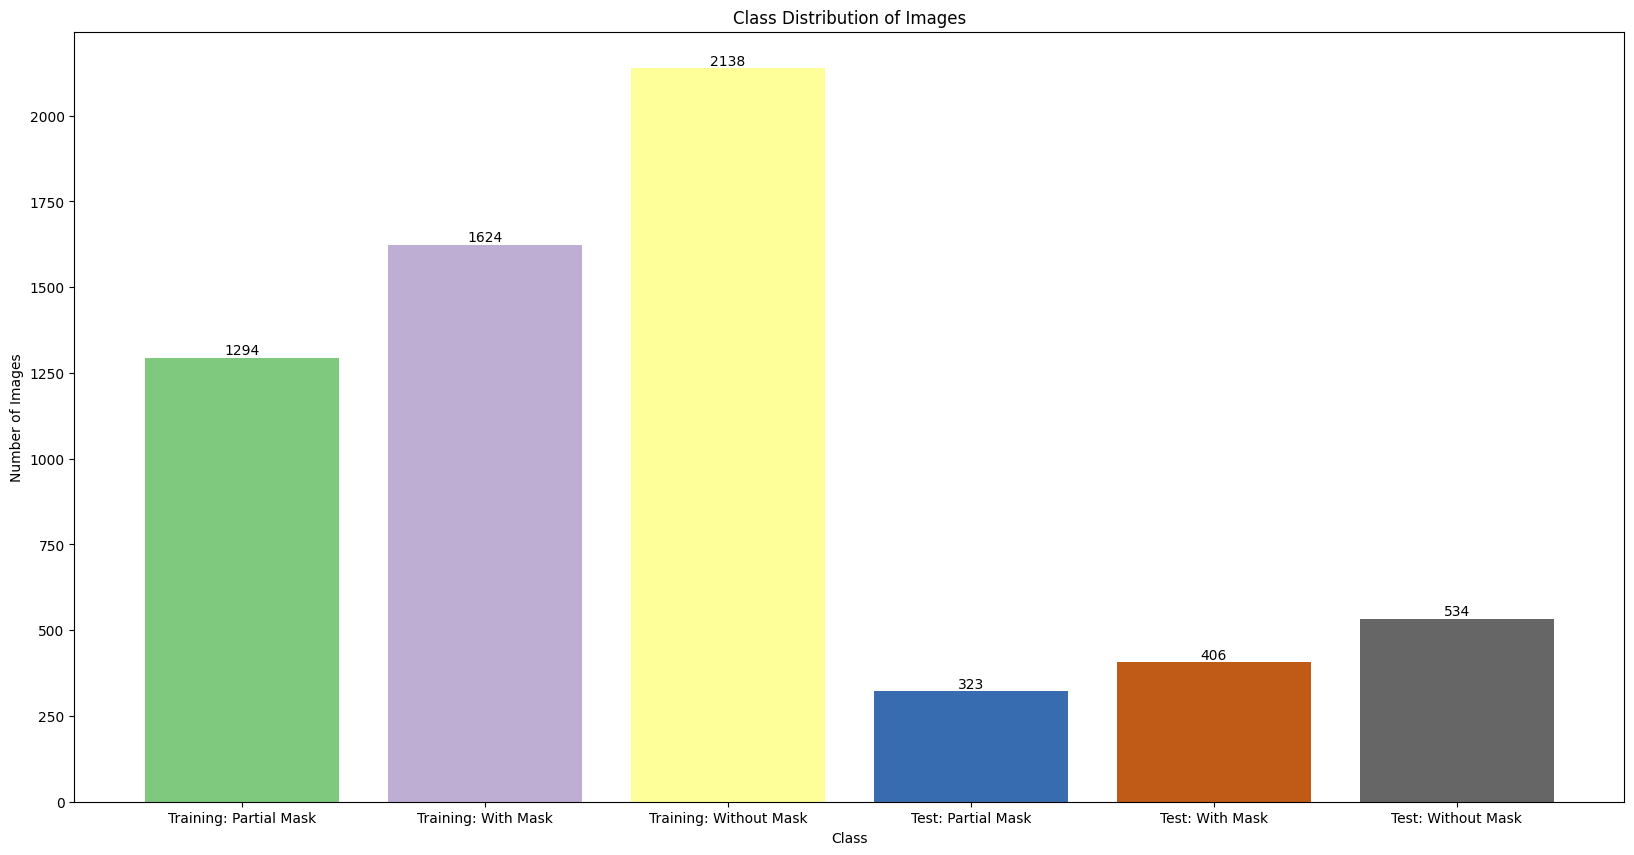

In [ ]:
classList = list(ImageCount.keys())
imageCountList = list(ImageCount.values())

plt.figure(figsize=(20, 10))

# Add title and labels
plt.title('Class Distribution of Images')
plt.xlabel('Class')
plt.ylabel('Number of Images')
# Generate colors from a colormap
cmap = plt.get_cmap('Accent')
colors = cmap(np.linspace(0, 1, len(classList)))

# Create a bar plot with colormap colors
classDistBarGraph = plt.bar(classList, imageCountList, color=colors)

for bar in classDistBarGraph:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height}', ha='center', va='bottom')

plt.show()

In [ ]:


def resize_images_in_folder(folder_path, target_size):
    # List all files and directories in the specified folder
    entries = os.listdir(folder_path)

    # Filter out only files (excluding directories)
    imageFiles = [entry for entry in entries if os.path.isfile(os.path.join(folder_path, entry))]

    # Get the count of files
    for imageFile in imageFiles:
        # Open the image file
        with Image.open(os.path.join(folder_path, imageFile)) as img:
            # Resize the image
            resized_img = img.resize(target_size)
            # Save the resized image
            resized_img.save(os.path.join(folder_path, imageFile))

In [ ]:
# Resize images to a standard size
input_image_size = (224, 224)

resize_images_in_folder('./MP2_FaceMask_Dataset/train/partial_mask', input_image_size)
resize_images_in_folder('./MP2_FaceMask_Dataset/train/with_mask', input_image_size)
resize_images_in_folder('./MP2_FaceMask_Dataset/train/without_mask', input_image_size)

resize_images_in_folder('./MP2_FaceMask_Dataset/test/partial_mask', input_image_size)
resize_images_in_folder('./MP2_FaceMask_Dataset/test/with_mask', input_image_size)
resize_images_in_folder('./MP2_FaceMask_Dataset/test/without_mask', input_image_size)

In [ ]:
# Create new directories for validation data
new_directory = './MP2_FaceMask_Dataset/validation/partial_mask'

# Create the new directory
try:
    os.makedirs(new_directory)
    print(f"Directory '{new_directory}' created successfully")
except FileExistsError:
    print(f"Directory '{new_directory}' already exists")

new_directory = './MP2_FaceMask_Dataset/validation/partial_mask'

# Create the new directory
new_directory = './MP2_FaceMask_Dataset/validation/with_mask'
try:
    os.makedirs(new_directory)
    print(f"Directory '{new_directory}' created successfully")
except FileExistsError:
    print(f"Directory '{new_directory}' already exists")

new_directory = './MP2_FaceMask_Dataset/validation/without_mask'

# Create the new directory
try:
    os.makedirs(new_directory)
    print(f"Directory '{new_directory}' created successfully")
except FileExistsError:
    print(f"Directory '{new_directory}' already exists")

Directory './MP2_FaceMask_Dataset/validation/partial_mask' already exists
Directory './MP2_FaceMask_Dataset/validation/with_mask' already exists
Directory './MP2_FaceMask_Dataset/validation/without_mask' already exists


In [ ]:
import os
import shutil
import random

def move_files(src_dir, dest_dir, split_ratio=0.2):
    # Ensure the destination directory exists
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    # List all files in the source directory
    files = os.listdir(src_dir)

    # Shuffle the list of files
    random.shuffle(files)

    # Calculate the number of files to move
    num_files_to_move = int(len(files) * split_ratio)

    # Move the files
    for file in files[:num_files_to_move]:
        src_file = os.path.join(src_dir, file)
        dest_file = os.path.join(dest_dir, file)
        shutil.move(src_file, dest_file)
        #print(f'Moved: {src_file} -> {dest_file}')

# Paths to the train and validation directories
train_dir = './MP2_FaceMask_Dataset/train'
validation_dir = './MP2_FaceMask_Dataset/validation'

# Move 20% of the files from each class folder
for class_folder in os.listdir(train_dir):
    class_train_dir = os.path.join(train_dir, class_folder)
    class_validation_dir = os.path.join(validation_dir, class_folder)

    # Ensure the validation class directory exists
    if not os.path.exists(class_validation_dir):
        os.makedirs(class_validation_dir)

    # Move the files
    move_files(class_train_dir, class_validation_dir, split_ratio=0.2)


In [ ]:
ImageCount = {}
ImageCount['Training: Partial Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/train/partial_mask')
ImageCount['Training: With Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/train/with_mask')
ImageCount['Training: Without Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/train/without_mask')
print(ImageCount)

ImageCount['Validation: Partial Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/validation/partial_mask')
ImageCount['Validation: With Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/validation/with_mask')
ImageCount['Validation: Without Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/validation/without_mask')


ImageCount['Test: Partial Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/test/partial_mask')
ImageCount['Test: With Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/test/with_mask')
ImageCount['Test: Without Mask'] = count_files_in_folder('./MP2_FaceMask_Dataset/test/without_mask')



print(ImageCount)

{'Training: Partial Mask': 1036, 'Training: With Mask': 1300, 'Training: Without Mask': 1711}
{'Training: Partial Mask': 1036, 'Training: With Mask': 1300, 'Training: Without Mask': 1711, 'Validation: Partial Mask': 470, 'Validation: With Mask': 589, 'Validation: Without Mask': 763, 'Test: Partial Mask': 323, 'Test: With Mask': 406, 'Test: Without Mask': 534}


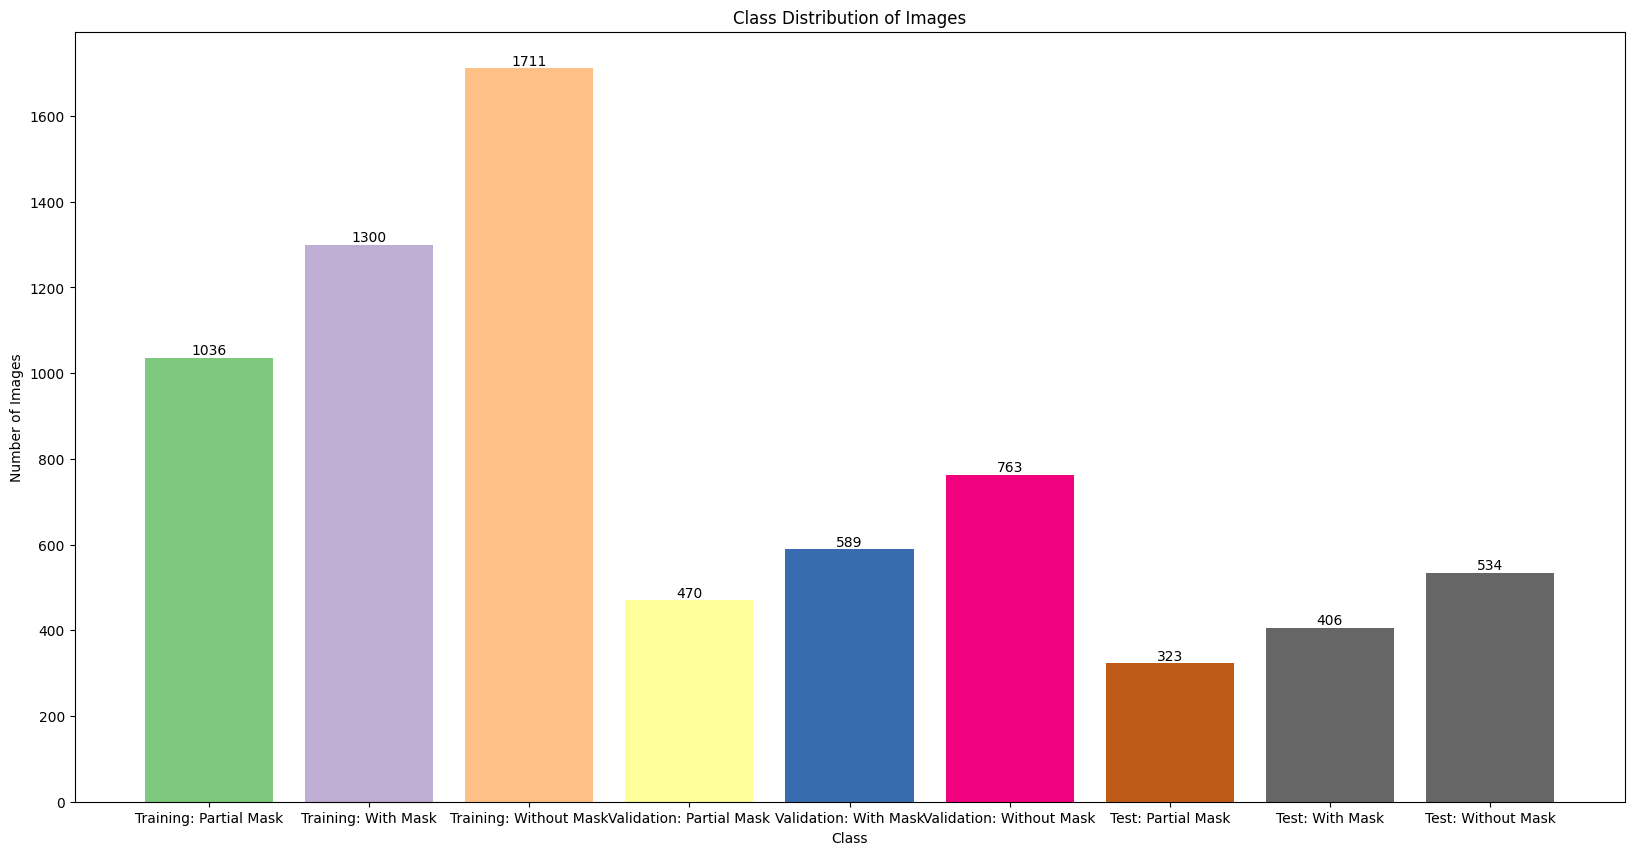

In [ ]:
classList = list(ImageCount.keys())
imageCountList = list(ImageCount.values())

plt.figure(figsize=(20, 10))

# Add title and labels
plt.title('Class Distribution of Images')
plt.xlabel('Class')
plt.ylabel('Number of Images')
# Generate colors from a colormap
cmap = plt.get_cmap('Accent')
colors = cmap(np.linspace(0, 1, len(classList)))

# Create a bar plot with colormap colors
classDistBarGraph = plt.bar(classList, imageCountList, color=colors)

for bar in classDistBarGraph:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height}', ha='center', va='bottom')

plt.show()

### Load the images using ImageDataGenerator

There are two main steps involved in creating the generator.
1. Instantiate ImageDataGenerator with required arguments to create an object
2. Use the `flow_from_directory` command depending on how your data is stored on disk. This is the command that will allow you to generate and get access to batches of data on the fly.

Hint: [link](https://keras.io/api/preprocessing/image/)

In [ ]:
TRAINING_DIR = "/content/MP2_FaceMask_Dataset/train/"
VALIDATION_DIR = "/content/MP2_FaceMask_Dataset/validation/"
TEST_DIR = "/content/MP2_FaceMask_Dataset/test/"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# YOUR CODE HERE
# Model Parameters
batch_size = 256

# Instantiate ImageDataGenerator
train_data_gen = ImageDataGenerator(rescale = 1.0/255,
                         width_shift_range = 0.005,
                         height_shift_range = 0.005,
                         rotation_range = 0,
                         horizontal_flip = True)

validation_data_gen = ImageDataGenerator(rescale = 1.0/255)

test_data_gen = ImageDataGenerator(rescale = 1.0/255)

# Flow
train_batches = train_data_gen.flow_from_directory(
    '/content/MP2_FaceMask_Dataset/train/',               # Directory path for training data
    target_size=input_image_size,        # Resize images
    batch_size=32)                 # Number of images to return in each batch)

val_batches = validation_data_gen.flow_from_directory(
    '/content/MP2_FaceMask_Dataset/validation/',
    target_size=input_image_size,        # Resize images
    batch_size=32,
    shuffle=False)                # Number of images to return in each batch

test_batches = test_data_gen.flow_from_directory(
    '/content/MP2_FaceMask_Dataset/test/',
    target_size=input_image_size,        # Resize images
    batch_size=32,
    shuffle=False)                # Number of images to return in each batch

Found 4026 images belonging to 3 classes.
Found 1809 images belonging to 3 classes.
Found 1259 images belonging to 3 classes.


In [ ]:
train_Basic_batches = train_batches
val_Basic_batches = val_batches
test_Basic_batches = test_batches

train_VGG16_feature_batches = train_batches
val_VGG16_feature_batches = val_batches
test_VGG16_feature_batches = test_batches

train_VGG16_no_weights_batches = train_batches
val_VGG16_no_weights_batches = val_batches
test_VGG16_no_weights_batches = test_batches

train_ResNet_feature_batches = train_batches
val_ResNet_feature_batches = val_batches
test_ResNet_feature_batches = test_batches

train_ResNet_fine_batches = train_batches
val_ResNet_fine_batches = val_batches
test_ResNet_fine_batches = test_batches


In [ ]:
# test_batches = test_data_gen.flow_from_directory(
#     '/content/MP2_FaceMask_Dataset/test/',
#     target_size=input_image_size,        # Resize images
#     batch_size=32,                 # Number of images to return in each batch
#     class_mode='sparse')

In [ ]:
len(train_batches.classes)

4026

In [ ]:
len(train_batches.labels)

4026

In [ ]:
# Check the size of samples
print("Total number of samples:", train_batches.n)
print("Batch size:", train_batches.batch_size)
print("Class indices:", train_batches.class_indices)

# Get a batch of data
images, labels = next(train_batches)

# Check the shape of the images and labels
print("Shape of images batch:", images.shape)
print("Shape of labels batch:", labels.shape)

Total number of samples: 4026
Batch size: 32
Class indices: {'partial_mask': 0, 'with_mask': 1, 'without_mask': 2}
Shape of images batch: (32, 224, 224, 3)
Shape of labels batch: (32, 3)


### Visualize the sample images of each class using data generator

Hint: plt.subplot

In [ ]:
# YOUR CODE HERE
# Get the class indices
class_indices = train_batches.class_indices
classes = list(class_indices.keys())
print(len(classes))

3


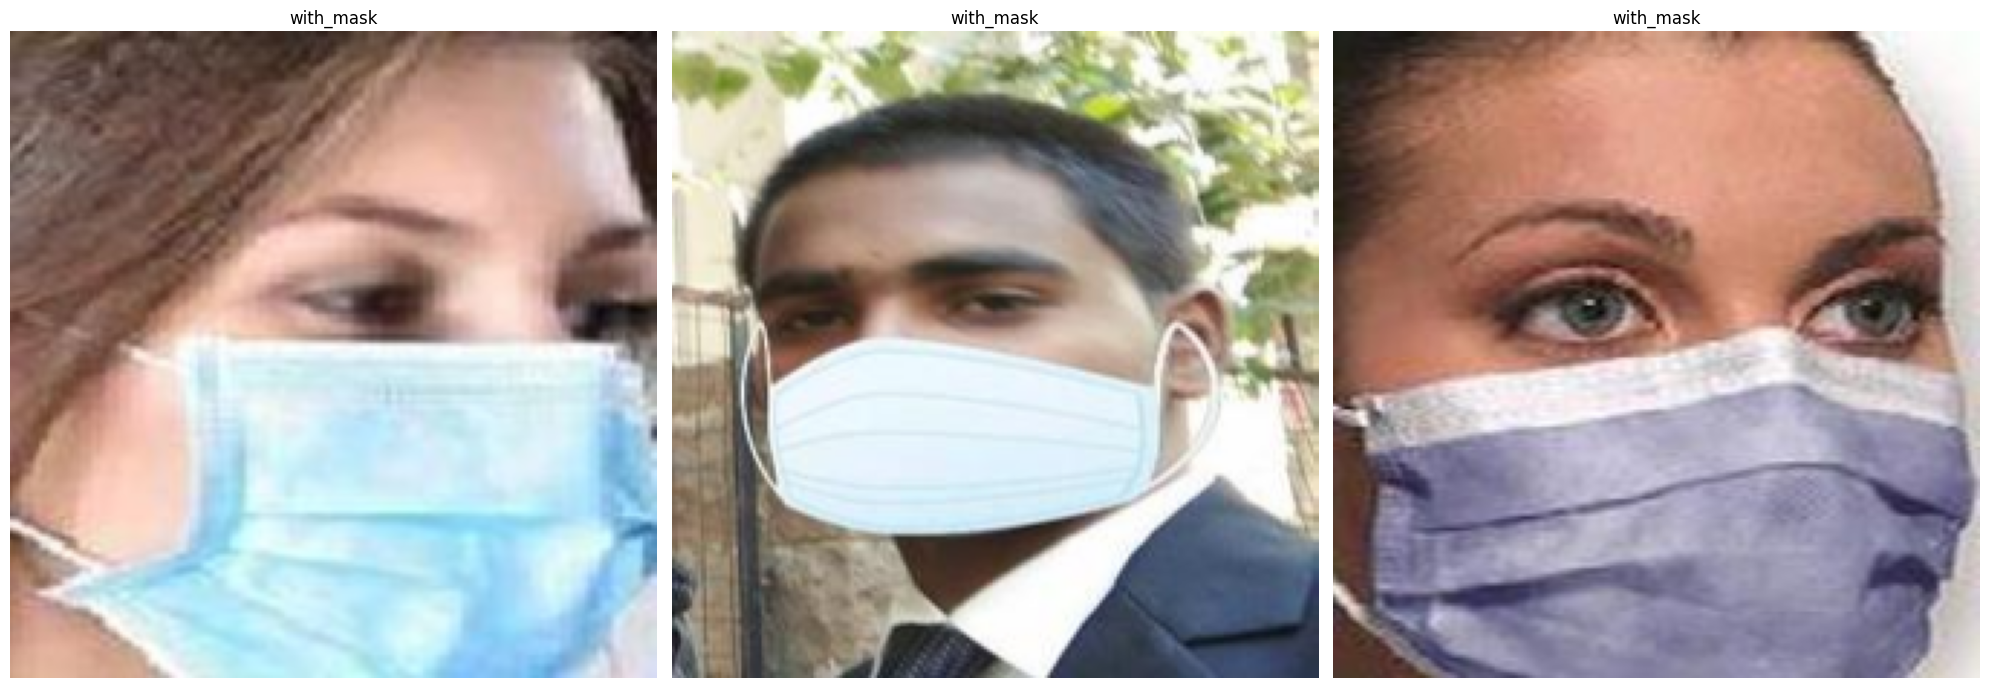

In [ ]:
# Function to plot images
def plot_images(images_arr, labels_arr, classes):
    fig, axes = plt.subplots(1, len(images_arr), figsize=(20,20))
    axes = axes.flatten()
    for img, lbl, ax in zip(images_arr, labels_arr, axes):
        ax.imshow(img)
        ax.set_title(classes[np.argmax(lbl)])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Fetch one batch of images
#images, labels = next(train_data_gen.flow(images, labels, batch_size=10))
images, labels = next(train_batches)

#print(labels)

# Show the images
#labels = labels.astype(int)
plot_images(images[:len(classes)], labels[:len(classes)], classes)

## Build the CNN model using Keras (4 points)



**Convolutional Neural Network:** A neural network in which at least one layer is a convolutional layer. A typical convolutional neural network consists of some combination of the following layers:

* convolutional layers
* pooling layers
* dense layers


**Conv2D**

Passing an image with input shape of 3-D and to calculate the output:

 $O = \frac{n - f + 2p}{s} + 1$

 where

 $n$ = image dimension

 $f$ = filter size

 $p$ = padding

 $s$ = stride

**MaxPool**

The resulting output, when using the "valid" padding option, has a spatial shape (number of rows or columns) of:

O = `math.floor`$(\frac{input shape - pool size)}{ strides}) + 1$ (when input shape >= pool size)

The resulting output shape when using the "same" padding option is:

O = `math.floor`$(\frac{input shape - 1}{strides}) + 1$

by default, stride = None, so stride is same as pool size

Task-flow
* Initialize the network of convolution, maxpooling and dense layers
* Define the optimizer and loss functions
* Fit the model and evaluate the model

In [ ]:
# YOUR CODE HERE
# Create model
model = Sequential([
                    Conv2D(64, 7, activation="relu", padding="same", input_shape=[224, 224, 3]),
                    MaxPooling2D(2),
                    Conv2D(128, 3, activation="relu", padding="same"),
                    Conv2D(128, 3, activation="relu", padding="same"),
                    MaxPooling2D(2),
                    Conv2D(256, 3, activation="relu", padding="same"),
                    Conv2D(256, 3, activation="relu", padding="same"),
                    MaxPooling2D(2),
                    Flatten(),
                    Dense(512, activation="relu"),
                    Dropout(0.5),
                    Dense(3, activation="softmax")
                    ])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [ ]:
# Set the number of epochs and steps per epoch
epochs = 10

# Fit the model
history = model.fit(
    train_batches,
    epochs=epochs,
    steps_per_epoch=len(train_batches),
    validation_data=val_batches,
    validation_steps=len(val_batches)
)



Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 73s 469ms/step - accuracy: 0.5774 - loss: 2.8173 - val_accuracy: 0.6108 - val_loss: 1.4922
Epoch 2/10


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


AttributeError: 'NoneType' object has no attribute 'items'

In [ ]:
# Evaluate the model on the validation data
loss, accuracy = model.evaluate(test_batches)

print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.9636 - loss: 0.1758
Test Loss: 0.16438037157058716
Test Accuracy: 0.9579030871391296


In [ ]:
images, labels = next(train_batches)

In [ ]:
images.shape, labels.shape

((32, 224, 224, 3), (32, 3))

In [ ]:
images, labels = next(test_batches)

In [ ]:
test_batches.n

1259

In [ ]:
y_actual = []
for index in range((test_batches.n//32)+1):
    images, labels = next(test_batches)
    y_actual.extend(np.argmax(labels, axis=1))

print(len(y_actual))
print(y_actual)


1259
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:
predictions_BasicModel = model.predict(test_batches)
print(predictions_BasicModel)
predBasicModel_classes = np.argmax(predictions_BasicModel, axis=1)
print(set(predBasicModel_classes))

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step
[[1.0000000e+00 1.0874949e-09 2.4920617e-12]
 [1.0000000e+00 1.1853187e-11 4.6626682e-17]
 [9.9906754e-01 9.3240762e-04 6.9679090e-10]
 ...
 [3.2337412e-05 1.5860488e-01 8.4136283e-01]
 [3.4433076e-06 2.1842772e-02 9.7815382e-01]
 [3.9564646e-03 3.2193574e-01 6.7410779e-01]]
{0, 1, 2}


In [ ]:
print(set(predBasicModel_classes))

{0, 1, 2}


In [ ]:
true_labels = test_batches.classes

In [ ]:
test_batches.class_indices

{'partial_mask': 0, 'with_mask': 1, 'without_mask': 2}

In [ ]:
true_labels

array([0, 0, 0, ..., 2, 2, 2], dtype=int32)

In [ ]:
test_batches.next()

In [ ]:
print(true_classes)

NameError: name 'true_classes' is not defined

In [ ]:
print(set(true_classes))

In [ ]:
test_batches.next()[0][0].shape

In [ ]:
plot_images(test_batches.next()[0][0:3], y_actual[0:3], classes)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_actual, predBasicModel_classes)

In [ ]:
y_actual

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax)
# plt.tight_layout()
plt.show()

In [ ]:
modelBasic = model

In [ ]:
modelBasic.save('./modelBasic.keras')

In [ ]:
!pip -qq install livelossplot

import livelossplot

# outputs epoch-by-epoch loss functions and accuracies at the end of each epoch of training
plot_losses = livelossplot.PlotLossesKeras()

In [ ]:
# Set the number of epochs and steps per epoch
epochs = 3

# Fit the model
history = model.fit(
    train_batches,
    epochs=epochs,
    steps_per_epoch=len(train_batches),
    callbacks=[plot_losses],
    validation_data=val_batches,
    validation_steps=len(val_batches)
)

In [ ]:
!pip install -q -U keras-tuner

In [ ]:
import keras_tuner

In [ ]:
# Basic model tweaked with grid seached parameters
model = Sequential([
                    Conv2D(64, 7, activation="relu", padding="same", input_shape=[224, 224, 3]),
                    MaxPooling2D(2),
                    Conv2D(128, 3, activation="relu", padding="same"),
                    Conv2D(128, 3, activation="relu", padding="same"),
                    MaxPooling2D(2),
                    Conv2D(256, 3, activation="relu", padding="same"),
                    Conv2D(256, 3, activation="relu", padding="same"),
                    MaxPooling2D(2),
                    Flatten(),
                    Dense(512, activation="relu"),
                    Dropout(0.5),
                    Dense(3, activation="softmax")
                    ])

In [ ]:
from kerastuner import HyperModel, Hyperband
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

class CNNHyperModel(HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(Conv2D(
            filters=hp.Int('filters_1', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('kernel_size_1', values=[3, 5]),
            activation='relu',
            input_shape=(224, 224, 3)
        ))
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Flatten())
        model.add(Dense(
            units=hp.Int('units', min_value=32, max_value=128, step=32),
            activation='relu'
        ))
        model.add(Dropout(hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))
        model.add(Dense(3, activation='softmax'))

        model.compile(
            optimizer=hp.Choice('optimizer', values=['adam', 'sgd']),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

hypermodel = CNNHyperModel()

tuner = Hyperband(
    hypermodel,
    objective='val_accuracy',
    max_epochs=5,   # Stan
    factor=3,
    directory='hyperband',
    project_name='M4_MP2'
)

In [ ]:
#tuner.search(X_train, y_train, epochs=50, validation_split=0.2)
tuner.search(train_batches, epochs=5, validation_data=val_batches)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
The hyperparameter search is complete. The optimal number of filters in the first Conv2D layer is {best_hps.get('filters_1')},
the optimal kernel size is {best_hps.get('kernel_size_1')}, and the optimal number of units in the Dense layer is {best_hps.get('units')}.
""")


In [ ]:
best_hps.values

In [ ]:
# Get the best model
best_model = tuner.hypermodel.build(best_hps)

In [ ]:
from keras.models import model_from_json

In [ ]:
# Save the model architecture to JSON
model_json = best_model.to_json()
with open("best_model.json", "w") as json_file:
    json_file.write(model_json)

print("Model architecture saved to best_model.json")

In [ ]:
with open("best_model.json", "r") as json_file:
    model_json = json_file.read()


best_model_restored = model_from_json(model_json)

In [ ]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])

In [ ]:
best_model_restored.compile(
            optimizer="nadam",
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
# from keras.backend import clear_session
# clear_session()

In [ ]:
# Set the number of epochs and steps per epoch
epochs = 10

# Fit the model
history = best_model_restored.fit(
    train_batches,
    epochs=epochs,
    steps_per_epoch=len(train_batches),
    validation_data=val_batches,
    validation_steps=len(val_batches))

In [ ]:
# Evaluate the model on the validation data
loss, accuracy = best_model_restored.evaluate(test_batches)

print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

## Transfer learning (4 points)

Transfer learning consists of taking features learned on one problem, and leveraging them on a new, similar problem.

A pre-trained model is a saved network that was previously trained on a large dataset, typically on a large-scale image-classification task.

The intuition behind transfer learning for image classification is that if a model is trained on a large and general enough dataset, this model will effectively serve as a generic model of the visual world. You can then take advantage of these learned feature maps without having to start from scratch by training a large model on a large dataset.

For eg. Using VGG16, we remove the last layer which takes a probability for each of the 1000 classes in the ImageNet and replaces it with a layer that takes 3 probabilities in our case.

### Use the pre-trained models ([VGG16](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/VGG16) or [ResNet50](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/ResNet50))

* Load the pre-trained model
* Fit and evaluate the data

Hint: [How to use pre-trained model](https://towardsdatascience.com/step-by-step-guide-to-using-pretrained-models-in-keras-c9097b647b29)

#### Expected accuracy: More than 90%

Task-flow
* Initialize the network with the weights of Imagenet
* Fine tune the network by modifying fully connected layers.
* Re-train the model with our problem data

***VGG16***

In [ ]:
from tensorflow import keras
from keras.applications import vgg16
from keras import layers
from keras.layers import Input, GlobalMaxPooling2D, BatchNormalization, Dropout, Dense
from keras.models import Model

In [ ]:
# YOUR CODE HERE

conv_base = keras.applications.vgg16.VGG16(
weights="imagenet",
include_top=False)
conv_base.trainable = False

In [ ]:
# VGG16 Feature Extraction model with Relu and additional dense layers (4096 etc)
# val_accuracy plateauing at 0.4257

data_augmentation = keras.Sequential(
[
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.2),
]
)
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(4096, activation="relu")(x)
x = layers.Dense(1024, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(train_batches.num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="categorical_crossentropy",
optimizer="nadam",
metrics=["accuracy"])

In [ ]:
# VGG16 Feature Extraction model from Version 5, has 0.7 accuracy

class_weights_dict = {0: 1.0, 1: 0.8, 2: 1.2}

data_augmentation = keras.Sequential(
[
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.2),
]
)
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="categorical_crossentropy",
optimizer="nadam",
metrics=["accuracy"])

In [ ]:
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="feature_extraction_with_data_augmentation.keras",
save_best_only=True,
monitor="val_loss")
]

In [ ]:
model.summary()

In [ ]:
history = model.fit(
train_batches,
epochs=10,
batch_size = 32,
validation_data=val_batches,
class_weight=class_weights_dict)

In [ ]:
# Evaluate the model on the validation data
loss, accuracy = model.evaluate(test_batches)

print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

In [ ]:
featureExtraction_VGG16_model = model

VGG16 without weights

In [ ]:
# YOUR CODE HERE
# VGG16 model without ImageNet weights (basic version)

conv_base = keras.applications.vgg16.VGG16(
weights=None,
include_top=True)
conv_base.trainable = True

data_augmentation = keras.Sequential(
[
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.2),
]
)
inputs = keras.Input(shape=(224, 224, 3))
# x = data_augmentation(inputs)
# x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(inputs)
x = layers.Flatten()(x)
x = layers.Dense(512)(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128)(x)
# x = layers.Dropout(0.5)(x)
x = layers.Dense(32)(x)
# x = layers.Dropout(0.5
outputs = layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [ ]:
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="feature_extraction_with_data_augmentation.keras",
save_best_only=True,
monitor="val_loss")
]

In [ ]:
model.summary()

In [ ]:
# VGG16 model without ImageNet weights (with additional dense layers, ReLU etc)

conv_base = keras.applications.vgg16.VGG16(
weights=None,
include_top=True)
conv_base.trainable = True

data_augmentation = keras.Sequential(
[
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.2),
]
)
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(4096, activation="relu", kernel_initializer="he_uniform")(x)
x = layers.Dense(1024, activation="relu", kernel_initializer="he_uniform")(x)
x = layers.Dense(256, activation="relu", kernel_initializer="he_uniform")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(train_batches.num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="categorical_crossentropy",
optimizer="nadam",
metrics=["accuracy"])

In [ ]:
history = model.fit(
train_VGG16_no_weights_batches,
epochs=5,
batch_size = 32,
validation_data=val_VGG16_no_weights_batches)

In [ ]:
# Evaluate the model on the validation data
loss, accuracy = model.evaluate(test_batches)

print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

*** RESNET50 ***

In [ ]:
from tensorflow import keras
from keras.applications import ResNet50
from keras.layers import Input, GlobalMaxPooling2D, BatchNormalization, Dropout, Dense
from keras.models import Model

# Load pre-trained ResNet50 model
resnet = ResNet50(weights='imagenet',include_top=False, pooling=None,input_shape = (224, 224, 3) ,classifier_activation='softmax')
num_classes = 3

def build_feature_extraction_model(resnet, num_classes, dropout_rate=0.5):
    # Freeze the pretrained model
    resnet.trainable = False

    input_data = Input(shape=(224, 224, 3))

    #Input Data
    x = resnet(input_data)

    # Add Global Max Pooling
    x = GlobalMaxPooling2D()(x)

     # Add Batch Normalization
    x = BatchNormalization()(x)

    # Add Dropout
    x = Dropout(dropout_rate)(x)

    # Add a Dense layer
    output = Dense(num_classes, activation="softmax")(x)

# Create the output model
    model = Model(inputs=input_data, outputs=output)

    return model

# Call the function to build the finetuned model
feature_extracted_Resnet50_model = build_feature_extraction_model(resnet,3,0.5)

feature_extracted_Resnet50_model.summary()



In [ ]:
# Compile the model
#finetuned_model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#ReduceLROnPlateau callback to adjust the learning rate during training.
from keras.callbacks import ReduceLROnPlateau

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=0.00001)

# Compile the model
feature_extracted_Resnet50_model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Train the model with ReduceLROnPlateau callback
history= feature_extracted_Resnet50_model.fit(
    train_batches,
    validation_data=val_batches,
    epochs=10,
    batch_size=32,
    callbacks=[reduce_lr]
    )


In [ ]:
 # Evaluate the model on the validation data
loss, accuracy = feature_extracted_Resnet50_model.evaluate(test_batches)

print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

***Fine Tuned Resnet50***

In [ ]:
from keras.layers import GlobalMaxPooling2D

In [ ]:
num_classes = 3

In [ ]:
conv_base = ResNet50(weights='imagenet',include_top=False, pooling=None,input_shape = (224, 224, 3) ,classifier_activation='softmax')
# conv_base.trainable = False

# conv_base.trainable = True
# print("This is the number of trainable weights before freezing the conv base:", len(conv_base.trainable_weights))
# conv_base.trainable = False
# print("This is the number of trainable weights after freezing the conv base:", len(conv_base.trainable_weights))
# Freezing all layers until the fourth from the last
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
 layer.trainable = False

x = conv_base.output
x= GlobalMaxPooling2D()(x)
x = Flatten()(x)
predictions = Dense(num_classes, activation='softmax')(x)

conv_base.summary()

# Create a new model with the modified architecture
model = keras.Model(inputs=conv_base.input, outputs=predictions)

model.compile(loss="sparse_categorical_crossentropy",
 optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
 metrics=["accuracy"])

callbacks = [
 keras.callbacks.ModelCheckpoint(
 filepath="fine_tuning.keras",
 save_best_only=True,
 monitor="val_loss")
]

# Train the model
history = model.fit(
 train_batches,
 epochs=10,
 validation_data=val_batches,
 callbacks=callbacks
)

# Evaluate the model on the validation data
loss, accuracy = model.evaluate(test_batches)

print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 1,054,720 (4.02 MB)

 Non-trainable params: 22,532,992 (85.96 MB)

Epoch 1/10


ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(None, 3), output.shape=(None, 3)

In [ ]:
fineTuned_Resnet50_model = model

In [ ]:
# Evaluate the model on the validation data
loss, accuracy = fineTuned_Resnet50_model.evaluate(test_batches)

print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

In [ ]:
/content/photo.jpg

### Capture the live image using the below code cell and predict

In [ ]:
#@title Capture the photo
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))
  display(Image(filename))
except Exception as err:
  print(str(err))

After executing above cell and capturing the photo, load the captured photo and predict with model.

**Note:**
* Convert the image to numpy array and resize to the shape which the model accepts.
* Extend the dimension (to 4-D shape) of an image, as the model is trained on a batch of inputs.

In [ ]:
# features = PIL.Image.open("photo.jpg")
# plt.imshow(features);
# YOUR CODE HERE to predict the image

In [ ]:
from PIL import Image

In [ ]:
photoImage = PIL.Image.open("photo.jpg")


In [ ]:
plt.imshow(photoImage)

In [ ]:
resizedPhotoImage = photoImage.resize((224, 224))

# Convert the image to a NumPy array (if not already)
photo_image_array = np.array(resizedPhotoImage)

# Extend the dimension to 4-D (batch size, height, width, channels)
# Assuming the model expects 3 color channels (RGB)
photo_image_array_4d = np.expand_dims(photo_image_array, axis=0)

# Now, image_array_4d is ready to be fed into the model
print(f"Original shape: {photoImage.size}")
print(f"Resized shape: {resizedPhotoImage.size}")
print(f"4-D shape of Photo Image Array: {photo_image_array_4d.shape}")

{'partial_mask': 0, 'with_mask': 1, 'without_mask': 2}

In [ ]:
photoImagePrediction = modelBasic.predict(photo_image_array_4d)
photoImage_classes = np.argmax(photoImagePrediction, axis=1)
photoImage_classes

In [ ]:
photoImagePrediction = featureExtraction_VGG16_model.predict(photo_image_array_4d)
photoImage_classes = np.argmax(photoImagePrediction, axis=1)
photoImage_classes


### Instructions for preparing Kaggle competition predictions

Important: Refer the [Kaggle Team Creation Instructions Doc](https://drive.google.com/file/d/1IgkHOXtJOw_wfsTrHBTl7kOOSMzhh3Ph/view?usp=drive_link)

* Load the image paths from Kaggle testset using `glob`
* Read the Images using `PIL.Image.open` and resize to required shape.
* Get the predictions using trained model and prepare a csv file
  - FC layer of DeepNet model gives output for each class, consider the maximum value among all classes as prediction using `np.argmax`.
* Predictions (csv) file should contain 2 columns as Sample_Submission.csv
  - First column is the img_path which is considered as index
  - Second column is prediction in decoded form (for eg. with_mask, partial_mask, without_mask).
  - Note that at the time of submission to Kaggle, predictions need to be sorted in ascending order i.e, same as sample submission file.

<font color='magenta'>If you are unable to download the data and sample submission from the Kaggle Competition site then please use the download cell below.</font>


In [ ]:
from google.colab import drive
import os
import shutil

# # Mount Google Drive
# drive.mount('/content/drive')

# Specify the directory containing the files
directory = './FaceMask_Kaggle_test'

# Check if the directory exists
if os.path.exists(directory):
    # Iterate through the files in the directory and delete them
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        try:
            # Check if it's a file and delete it
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
                #print(f'Deleted file: {file_path}')
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
                print(f'Deleted directory: {file_path}')
        except Exception as e:
            print(f'Failed to delete {file_path}. Reason: {e}')
else:
    print(f'The directory {directory} does not exist.')

print('Deletion complete.')


In [ ]:
#@title Download test data and SampleSubmission file for Kaggle submission
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/FaceMask_Kaggle_test.zip
!unzip -qq FaceMask_Kaggle_test.zip
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/Sample_Submission.csv
print("Data Downloaded Successfuly!!")

In [ ]:
!unzip -qq FaceMask_Kaggle_test.zip

In [ ]:


# Define the folder path
folder_path = './FaceMask_Kaggle_test'

# List all files in the folder
files = os.listdir(folder_path)

# Loop through the files and rename them
for filename in files:
    if filename.endswith('jpeg'):
        # Define the new filename
        new_filename = filename.replace('jpeg', '.jpg')

        # Get the full path to the old and new filenames
        old_file = os.path.join(folder_path, filename)
        new_file = os.path.join(folder_path, new_filename)

        # Rename the file
        os.rename(old_file, new_file)

print("Renaming completed!")


In [ ]:
from PIL import Image

In [ ]:
# Analyzing images in Kaggle test folder

# Specify the path to your folder
folder_path = './FaceMask_Kaggle_test'

# Analyze the image shapes
shapes = analyze_image_shapes(folder_path)

# Optionally, you can further analyze the shapes
unique_shapes = set(shapes)
print(f"Unique image shapes: {unique_shapes}")

In [ ]:
# Resize images to a standard size
input_image_size = (224, 224)

resize_images_in_folder('./FaceMask_Kaggle_test', input_image_size)

In [ ]:
# Define the directory containing the test images
test_dir = './FaceMask_Kaggle_test'

# Create a dummy subdirectory
dummy_subdir = os.path.join(test_dir, 'all')
os.makedirs(dummy_subdir, exist_ok=True)

# Move all images to the dummy subdirectory
for filename in os.listdir(test_dir):
    file_path = os.path.join(test_dir, filename)
    if os.path.isfile(file_path):
        shutil.move(file_path, os.path.join(dummy_subdir, filename))

# Verify the new structure
print(f"Images moved to {dummy_subdir}")

In [ ]:
kaggle_test_data_gen = ImageDataGenerator(rescale = 1.0/255)

kaggle_test_batches = kaggle_test_data_gen.flow_from_directory(
    '/content/FaceMask_Kaggle_test/',
    target_size=input_image_size,        # Resize images
    color_mode='rgb',
    batch_size=32,                 # Number of images to return in each batch
    class_mode=None,
    shuffle=False,
    seed=42,
    follow_links=False)

In [ ]:
print(kaggle_test_batches.filenames)

In [ ]:
type(kaggle_test_batches.filenames)

In [ ]:
kagglePredModel = modelBasic
#kagglePredModel = best_model_restored
#kagglePredModel = fineTuned_Resnet50_2
#kagglePredModel = featureExtraction_VGG16_model
kagglePredictions = kagglePredModel.predict(kaggle_test_batches)

In [ ]:
kagglePredictions

In [ ]:
predicted_classes = np.argmax(kagglePredictions, axis=1)
print("Predicted classes:", predicted_classes)

In [ ]:
predicted_classes_list = predicted_classes.tolist()
dfKagglePredictions = pd.DataFrame()
dfKagglePredictions['img_path'] = kaggle_test_batches.filenames
dfKagglePredictions['label'] = predicted_classes_list

dfKagglePredictions['label'] = dfKagglePredictions['label'].replace({0: 'partial_mask', 1: 'with_mask', 2: 'without_mask'})
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('all', 'FaceMask_Kaggle_test')

dfKagglePredictions['extracted'] = dfKagglePredictions['img_path'].str.extract(r'/(\d+)\.').astype(int)

# Sort the DataFrame based on the extracted integer values
dfKagglePredictions = dfKagglePredictions.sort_values(by='extracted')

# Drop the temporary column if you no longer need it
dfKagglePredictions = dfKagglePredictions.drop(columns=['extracted'])

dfKagglePredictions = dfKagglePredictions.reset_index()

dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/112.jpg', '/112jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/130.jpg', '/130jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/136.jpg', '/136jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/142.jpg', '/142jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/266.jpg', '/266jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/342.jpg', '/342jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/383.jpg', '/383jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/463.jpg', '/463jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/470.jpg', '/470jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/552.jpg', '/552jpeg')
dfKagglePredictions['img_path'] = dfKagglePredictions['img_path'].str.replace('/623.jpg', '/623jpeg')

In [ ]:
dfKagglePredictions[['img_path','label']].to_csv("Team12_Submission_8.csv",index = False, sep = ',')

In [ ]:

dfKagglePredictions

In [ ]:
dfKagglePredictions.info()


### Report Analysis

- Compare the accuracies for the Pre-trained vs CNN models
- What process was followed to tune the hyperparameters?
- Which model detects the mask/no mask/ partial mask more accurately with the live pictures?
- Discuss the confusion matrix in terms of the misclassifications